# Report Visuals

This notebook recreates the main report visuals for the project, including:
1. panel coverage by year
2. target distribution
3. California housing price shift before and after COVID
4. Model 1 predicted vs actual scatter plots
5. Model 2 predicted vs actual scatter plots
6. Model 1 vs Model 2 performance comparison


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'model-ready').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing model-ready/.')

DATA_DIR = PROJECT_ROOT / 'model-ready'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'report-figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = 'target_median_sale_price_log_change_next_year'

BASELINE_FEATURE_COLUMNS = [
    'year',
    'annual_homes_sold',
    'annual_pending_sales',
    'annual_new_listings',
    'annual_inventory_mean',
    'annual_inventory_end',
    'annual_months_of_supply_est',
    'annual_median_sale_price',
    'annual_median_list_price',
    'annual_median_ppsf',
    'annual_median_list_ppsf',
    'annual_avg_sale_to_list',
    'annual_sold_above_list',
    'annual_off_market_in_two_weeks',
    'annual_median_dom',
    'log_total_population',
    'log_median_household_income',
    'median_household_income_missing',
    'age_0_17_share',
    'age_18_24_share',
    'age_25_34_share',
    'age_35_44_share',
    'age_45_64_share',
    'education_less_than_high_school_share',
    'education_some_college_or_associates_share',
    'education_bachelors_or_higher_share',
    'foreign_born_total_share',
    'native_born_other_state_us_share',
    'born_other_state_25plus_bachelors_or_higher_share',
    'foreign_born_25plus_bachelors_or_higher_share',
]

EXTENDED_FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + [
    'is_caaspp',
    'n_schools',
    'log1p_n_schools',
    'avg_pct_met_overall_z_assessment_year',
    'avg_pct_met_ela_z_assessment_year',
    'avg_pct_met_math_z_assessment_year',
    'median_pct_met_overall_z_assessment_year',
    'overall_score_range',
]

def build_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])

def load_frames():
    listings = pd.read_csv(DATA_DIR / 'listings_model_ready.csv')
    demographics = pd.read_csv(DATA_DIR / 'zcta_demographics_features.csv')
    school = pd.read_csv(DATA_DIR / 'school_quality_features.csv')

    for frame in (listings, demographics, school):
        frame['zcta5'] = frame['zcta5'].astype(str).str.zfill(5)

    return listings, demographics, school

def build_baseline_panel(listings, demographics):
    panel = listings.merge(demographics, on=['zcta5', 'year'], how='inner', validate='one_to_one')
    panel = panel[panel['baseline_model_eligible'] & panel['demographics_baseline_eligible']].copy()
    return panel.sort_values(['year', 'zcta5']).reset_index(drop=True)

def build_extended_panel(listings, demographics, school):
    panel = build_baseline_panel(listings, demographics).merge(
        school, on=['zcta5', 'year'], how='inner', validate='one_to_one'
    )
    panel = panel[panel['school_quality_extended_eligible']].copy()
    return panel.sort_values(['year', 'zcta5']).reset_index(drop=True)

def prepare_xy(panel, feature_columns):
    X = panel[feature_columns].copy()
    for col in ['median_household_income_missing', 'is_caaspp']:
        if col in X.columns:
            X[col] = X[col].astype(int)
    y = panel[TARGET_COLUMN].astype(float)
    return X, y

def evaluate_predictions(y_true, y_pred):
    return {
        'rows': int(len(y_true)),
        'rmse': float(mean_squared_error(y_true, y_pred) ** 0.5),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }

def temporal_evaluation(panel, feature_columns, train_year_max, valid_year_min, valid_year_max):
    X, y = prepare_xy(panel, feature_columns)
    train_mask = panel['year'] <= train_year_max
    valid_mask = panel['year'].between(valid_year_min, valid_year_max)

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()
    X_valid = X.loc[valid_mask].copy()
    y_valid = y.loc[valid_mask].copy()

    model = build_model()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    return {
        'model': model,
        'train_metrics': evaluate_predictions(y_train, train_pred),
        'test_metrics': evaluate_predictions(y_valid, valid_pred),
        'y_test': y_valid,
        'pred_test': valid_pred,
    }

def grouped_evaluation(panel, feature_columns, random_state=42):
    X, y = prepare_xy(panel, feature_columns)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X, y, groups=panel['zcta5']))

    X_train = X.iloc[train_idx].copy()
    y_train = y.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()

    model = build_model()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        'model': model,
        'train_metrics': evaluate_predictions(y_train, train_pred),
        'test_metrics': evaluate_predictions(y_test, test_pred),
        'y_test': y_test,
        'pred_test': test_pred,
    }

def log_to_pct(values):
    return (np.exp(values) - 1.0) * 100.0

def metrics_row(model_name, sample_name, evaluation_name, metrics):
    return {
        'model': model_name,
        'sample': sample_name,
        'evaluation': evaluation_name,
        'rows': int(metrics['rows']),
        'rmse_log': metrics['rmse'],
        'mae_log': metrics['mae'],
        'r2': metrics['r2'],
        'rmse_pct_approx': metrics['rmse'] * 100.0,
        'mae_pct_approx': metrics['mae'] * 100.0,
    }

In [3]:
listings, demographics, school = load_frames()

listings_panel = listings[listings['baseline_model_eligible']].copy()
baseline_panel = build_baseline_panel(listings, demographics)
extended_panel = build_extended_panel(listings, demographics, school)

matched_keys = extended_panel[['zcta5', 'year']].copy()
baseline_matched_panel = baseline_panel.merge(
    matched_keys, on=['zcta5', 'year'], how='inner', validate='one_to_one'
)

print(f'DATA_DIR: {DATA_DIR}')
print(f'Listings panel rows: {len(listings_panel):,}')
print(f'Baseline panel rows: {len(baseline_panel):,}')
print(f'Extended panel rows: {len(extended_panel):,}')
print(f'Matched comparison rows: {len(baseline_matched_panel):,}')

DATA_DIR: /Users/charlesgao/Desktop/spring2026/stats170B/project/model-ready
Listings panel rows: 11,595
Baseline panel rows: 11,561
Extended panel rows: 8,787
Matched comparison rows: 8,787


## Figure 1: Panel Coverage By Year

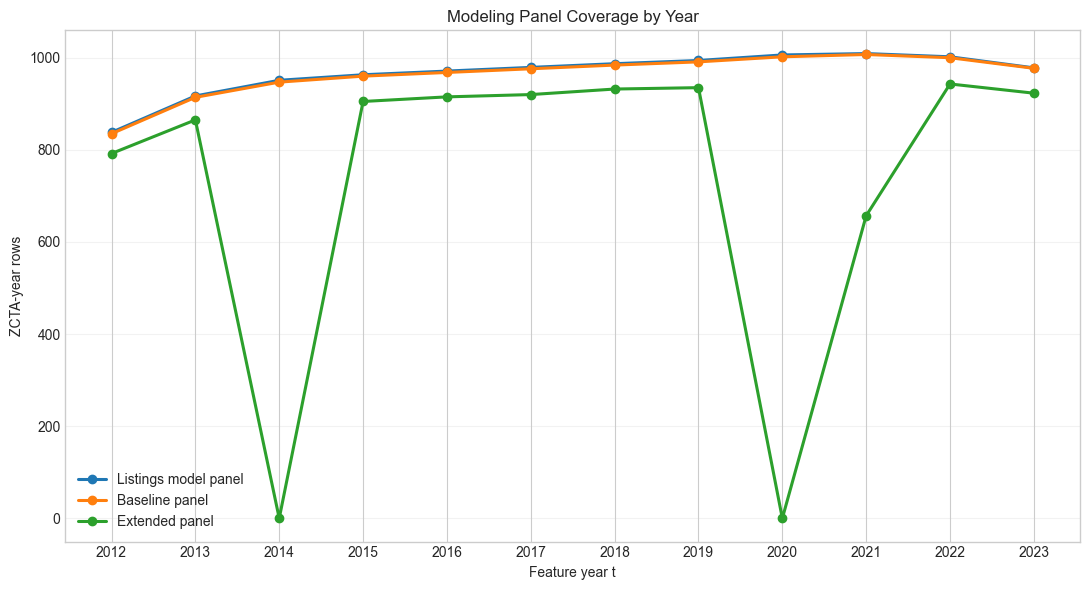

,Listings model panel,Baseline panel,Extended panel
year,,,
2012,838,835,792
2013,917,914,865
2014,951,947,0
2015,963,960,905
2016,971,968,915
2017,979,976,920
2018,987,984,932
2019,994,991,935
2020,1006,1002,0


In [4]:
year_index = pd.Index(
    range(
        int(min(listings_panel['year'].min(), baseline_panel['year'].min(), extended_panel['year'].min())),
        int(max(listings_panel['year'].max(), baseline_panel['year'].max(), extended_panel['year'].max())) + 1,
    ),
    name='year',
)

coverage = pd.DataFrame({
    'Listings model panel': listings_panel.groupby('year').size().reindex(year_index, fill_value=0),
    'Baseline panel': baseline_panel.groupby('year').size().reindex(year_index, fill_value=0),
    'Extended panel': extended_panel.groupby('year').size().reindex(year_index, fill_value=0),
})

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(coverage.index, coverage['Listings model panel'], marker='o', linewidth=2.2, label='Listings model panel')
ax.plot(coverage.index, coverage['Baseline panel'], marker='o', linewidth=2.2, label='Baseline panel')
ax.plot(coverage.index, coverage['Extended panel'], marker='o', linewidth=2.2, label='Extended panel')
ax.set_title('Modeling Panel Coverage by Year')
ax.set_xlabel('Feature year t')
ax.set_ylabel('ZCTA-year rows')
ax.set_xticks(list(coverage.index))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_panel_coverage_by_year.png', dpi=200)
coverage.reset_index().to_csv(FIG_DIR / '01_panel_coverage_by_year.csv', index=False)
plt.show()
coverage

## Figure 2: Target Distribution

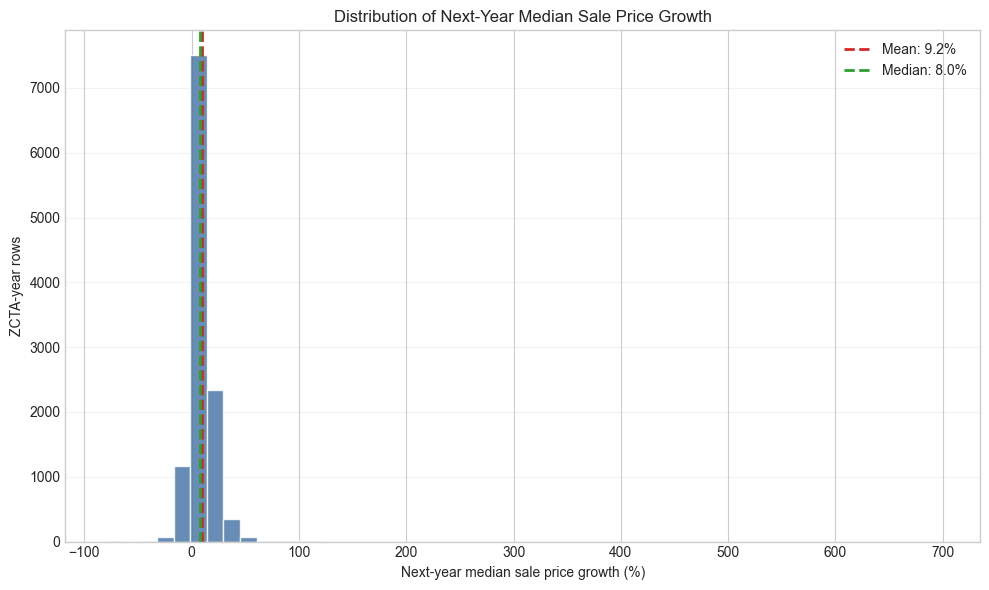

count    11561.000000
mean         9.155921
std         12.757294
min        -78.939295
25%          3.343575
50%          7.992373
75%         13.710244
max        695.966894
Name: target_pct, dtype: float64

In [5]:
growth_pct = pd.Series(log_to_pct(baseline_panel[TARGET_COLUMN]), name='target_pct')
mean_value = float(growth_pct.mean())
median_value = float(growth_pct.median())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(growth_pct, bins=50, color='#4c78a8', alpha=0.85, edgecolor='white')
ax.axvline(mean_value, color='#d62728', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.1f}%')
ax.axvline(median_value, color='#2ca02c', linestyle='--', linewidth=2, label=f'Median: {median_value:.1f}%')
ax.set_title('Distribution of Next-Year Median Sale Price Growth')
ax.set_xlabel('Next-year median sale price growth (%)')
ax.set_ylabel('ZCTA-year rows')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_target_distribution.png', dpi=200)
plt.show()
growth_pct.describe()

## Figure 3: California Housing Price Shift Before and After COVID

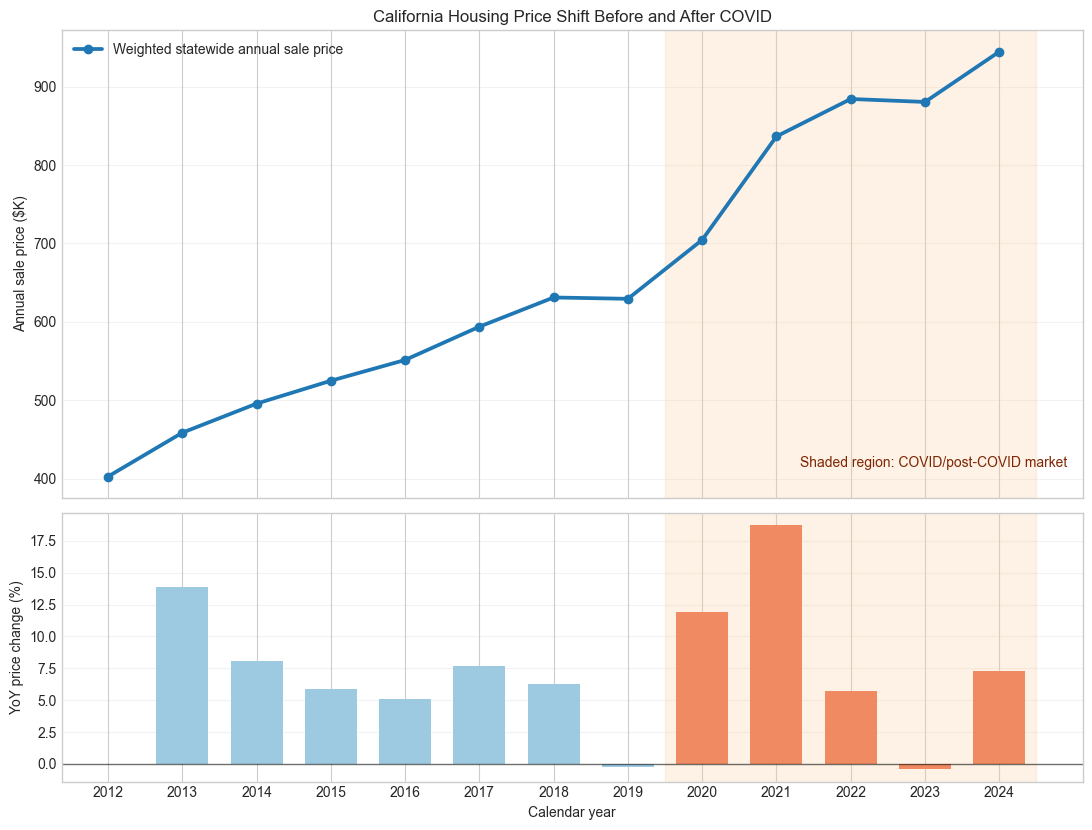

,year,statewide_sale_price,statewide_homes_sold,zcta_count,statewide_sale_price_k,yoy_price_change_pct
0,2012,402479.946039,874941.0,968,402.479946,NaN
1,2013,458416.046652,998613.0,1084,458.416047,13.897860
2,2014,495509.924073,928872.0,1082,495.509924,8.091749
3,2015,524728.853481,1034458.0,1157,524.728853,5.896739
4,2016,551253.183258,1017034.0,1124,551.253183,5.054864
5,2017,593718.292764,1041291.0,1143,593.718293,7.703377
6,2018,630996.041432,976227.0,1146,630.996041,6.278693
7,2019,629288.763743,992265.0,1155,629.288764,-0.270569
8,2020,704488.280982,999355.0,1159,704.488281,11.949922
9,2021,836504.990747,1165838.0,1178,836.504991,18.739376


In [6]:
annual_listings = pd.read_csv(
    DATA_DIR / 'listings_annual_all_residential.csv',
    usecols=['year', 'full_year_coverage', 'annual_homes_sold', 'annual_median_sale_price']
)
annual_listings = annual_listings[
    annual_listings['full_year_coverage']
    & annual_listings['annual_median_sale_price'].notna()
    & (annual_listings['annual_homes_sold'].fillna(0) > 0)
].copy()

statewide_rows = []
for year, group in annual_listings.groupby('year', sort=True):
    weights = group['annual_homes_sold'].to_numpy(dtype=float)
    prices = group['annual_median_sale_price'].to_numpy(dtype=float)
    statewide_rows.append(
        {
            'year': int(year),
            'statewide_sale_price': float(np.average(prices, weights=weights)),
            'statewide_homes_sold': float(weights.sum()),
            'zcta_count': int(len(group)),
        }
    )

statewide_price = pd.DataFrame(statewide_rows).sort_values('year').reset_index(drop=True)
statewide_price['statewide_sale_price_k'] = statewide_price['statewide_sale_price'] / 1000.0
statewide_price['yoy_price_change_pct'] = statewide_price['statewide_sale_price'].pct_change() * 100.0

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8.4),
    sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.15]},
)

covid_start = 2019.5
covid_end = float(statewide_price['year'].max()) + 0.5
for ax in axes:
    ax.axvspan(covid_start, covid_end, color='#fdd0a2', alpha=0.28)

axes[0].plot(
    statewide_price['year'],
    statewide_price['statewide_sale_price_k'],
    marker='o',
    linewidth=2.7,
    color='#1f77b4',
    label='Weighted statewide annual sale price',
)
axes[0].set_title('California Housing Price Shift Before and After COVID')
axes[0].set_ylabel('Annual sale price ($K)')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, loc='upper left')
axes[0].text(
    0.985,
    0.06,
    'Shaded region: COVID/post-COVID market',
    transform=axes[0].transAxes,
    ha='right',
    va='bottom',
    fontsize=10,
    color='#7f2704',
)

bar_colors = ['#9ecae1' if year < 2020 else '#ef8a62' for year in statewide_price['year']]
axes[1].bar(
    statewide_price['year'],
    statewide_price['yoy_price_change_pct'],
    color=bar_colors,
    width=0.7,
)
axes[1].axhline(0, color='black', linewidth=1, alpha=0.55)
axes[1].set_xlabel('Calendar year')
axes[1].set_ylabel('YoY price change (%)')
axes[1].set_xticks(statewide_price['year'].tolist())
axes[1].grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / '03_statewide_housing_price_shift.png', dpi=200)
statewide_price.to_csv(FIG_DIR / '03_statewide_housing_price_shift.csv', index=False)
plt.show()
statewide_price


## Model Evaluations Used In The Report

In [7]:
baseline_temporal = temporal_evaluation(
    baseline_panel, BASELINE_FEATURE_COLUMNS, train_year_max=2020, valid_year_min=2021, valid_year_max=2023
)
baseline_grouped = grouped_evaluation(baseline_panel, BASELINE_FEATURE_COLUMNS)

baseline_matched_temporal = temporal_evaluation(
    baseline_matched_panel, BASELINE_FEATURE_COLUMNS, train_year_max=2019, valid_year_min=2021, valid_year_max=2023
)
baseline_matched_grouped = grouped_evaluation(baseline_matched_panel, BASELINE_FEATURE_COLUMNS)
extended_temporal = temporal_evaluation(
    extended_panel, EXTENDED_FEATURE_COLUMNS, train_year_max=2019, valid_year_min=2021, valid_year_max=2023
)
extended_grouped = grouped_evaluation(extended_panel, EXTENDED_FEATURE_COLUMNS)

metrics_df = pd.DataFrame([
    metrics_row('Model 1', 'Full baseline sample', 'Temporal validation', baseline_temporal['test_metrics']),
    metrics_row('Model 1', 'Full baseline sample', 'Grouped-ZCTA test', baseline_grouped['test_metrics']),
    metrics_row('Model 1', 'Matched school sample', 'Temporal validation', baseline_matched_temporal['test_metrics']),
    metrics_row('Model 1', 'Matched school sample', 'Grouped-ZCTA test', baseline_matched_grouped['test_metrics']),
    metrics_row('Model 2', 'Matched school sample', 'Temporal validation', extended_temporal['test_metrics']),
    metrics_row('Model 2', 'Matched school sample', 'Grouped-ZCTA test', extended_grouped['test_metrics']),
])

metrics_df.to_csv(FIG_DIR / 'model_comparison_metrics.csv', index=False)
metrics_df

,model,sample,evaluation,rows,rmse_log,mae_log,r2,rmse_pct_approx,mae_pct_approx
0,Model 1,Full baseline sample,Temporal validation,2984,0.094037,0.068825,-0.097180,9.403709,6.882515
1,Model 1,Full baseline sample,Grouped-ZCTA test,2341,0.089565,0.058304,0.201442,8.956466,5.830447
2,Model 1,Matched school sample,Temporal validation,2523,0.088240,0.062484,-0.090184,8.824041,6.248416
3,Model 1,Matched school sample,Grouped-ZCTA test,1751,0.080031,0.052800,0.248352,8.003135,5.280012
4,Model 2,Matched school sample,Temporal validation,2523,0.085577,0.059906,-0.025376,8.557741,5.990556
5,Model 2,Matched school sample,Grouped-ZCTA test,1751,0.079148,0.051752,0.264846,7.914836,5.175170


## Figure 4: Model 1 Predicted vs Actual

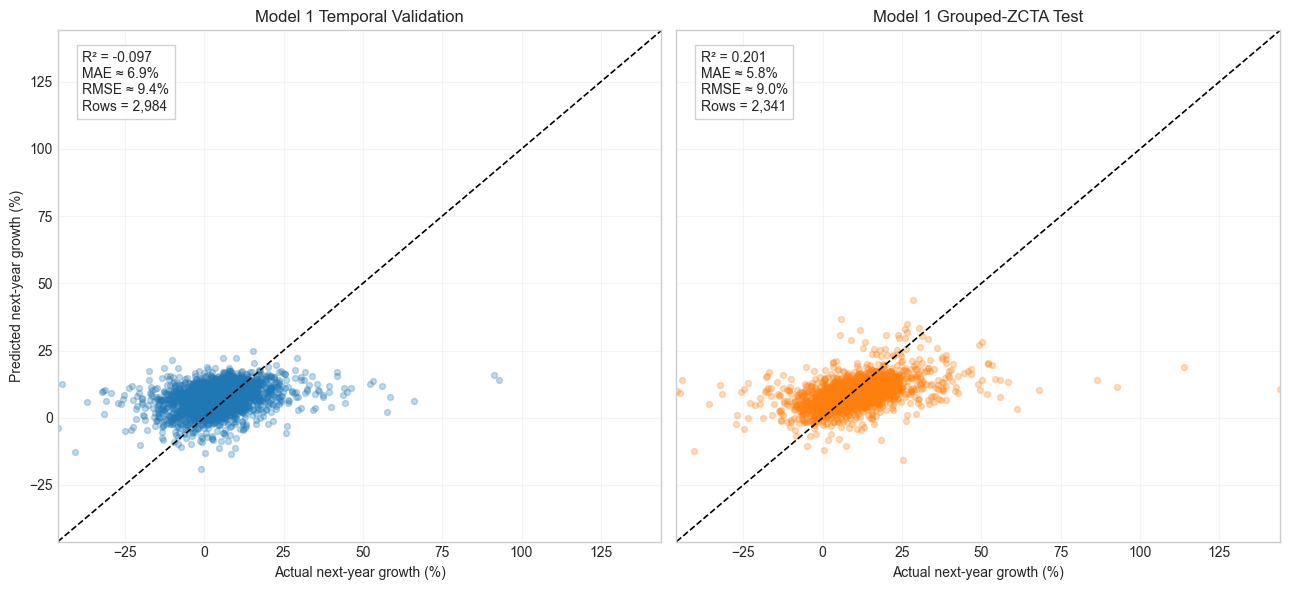

In [8]:
def add_metric_text(ax, metrics):
    text = '\n'.join([
        f'R² = {metrics["r2"]:.3f}',
        f'MAE ≈ {metrics["mae"] * 100:.1f}%',
        f'RMSE ≈ {metrics["rmse"] * 100:.1f}%',
        f'Rows = {int(metrics["rows"]):,}',
    ])
    ax.text(
        0.04, 0.96, text, transform=ax.transAxes, va='top', ha='left', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9},
    )

actual_temporal = log_to_pct(baseline_temporal['y_test'])
pred_temporal = log_to_pct(baseline_temporal['pred_test'])
actual_grouped = log_to_pct(baseline_grouped['y_test'])
pred_grouped = log_to_pct(baseline_grouped['pred_test'])

global_min = float(min(actual_temporal.min(), pred_temporal.min(), actual_grouped.min(), pred_grouped.min()))
global_max = float(max(actual_temporal.max(), pred_temporal.max(), actual_grouped.max(), pred_grouped.max()))
lims = [global_min, global_max]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
plots = [
    (axes[0], actual_temporal, pred_temporal, 'Model 1 Temporal Validation', baseline_temporal['test_metrics'], '#1f77b4'),
    (axes[1], actual_grouped, pred_grouped, 'Model 1 Grouped-ZCTA Test', baseline_grouped['test_metrics'], '#ff7f0e'),
]

for ax, actual, predicted, title, metrics, color in plots:
    ax.scatter(actual, predicted, alpha=0.28, s=18, color=color)
    ax.plot(lims, lims, linestyle='--', color='black', linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Actual next-year growth (%)')
    ax.grid(alpha=0.2)
    add_metric_text(ax, metrics)

axes[0].set_ylabel('Predicted next-year growth (%)')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_model1_predicted_vs_actual.png', dpi=200)
fig.savefig(FIG_DIR / 'model1_scatter_validation_methods.png', dpi=200)
plt.show()

## Figure 5: Model 2 Predicted vs Actual

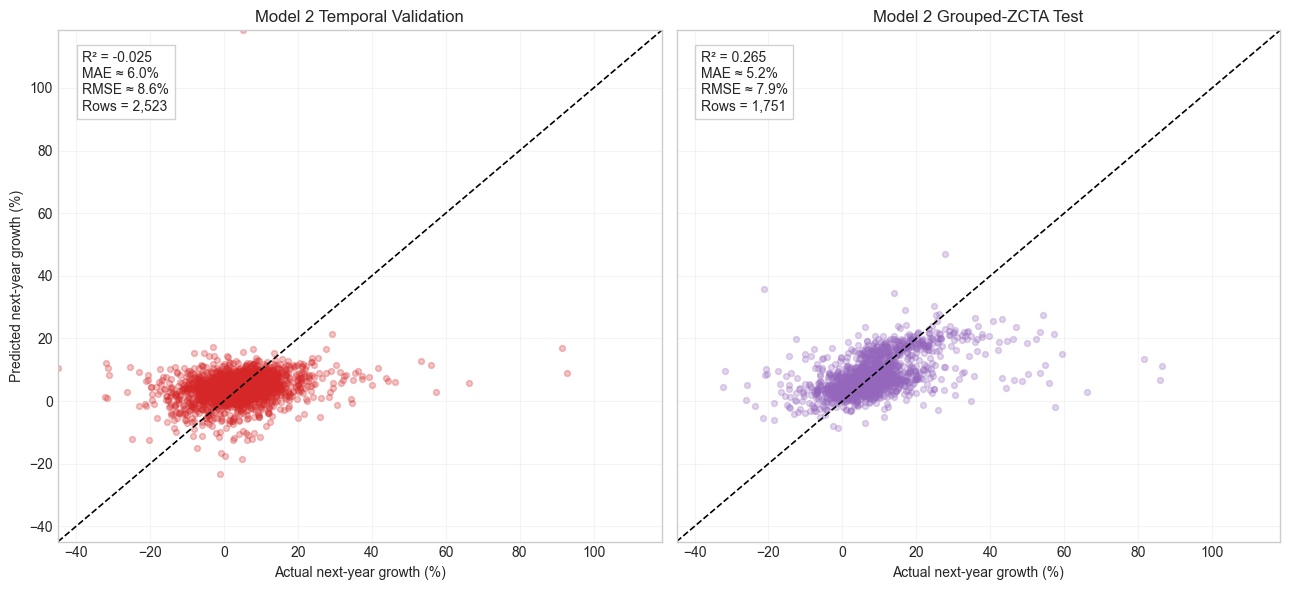

In [9]:
actual_temporal_model2 = log_to_pct(extended_temporal['y_test'])
pred_temporal_model2 = log_to_pct(extended_temporal['pred_test'])
actual_grouped_model2 = log_to_pct(extended_grouped['y_test'])
pred_grouped_model2 = log_to_pct(extended_grouped['pred_test'])

global_min_model2 = float(min(
    actual_temporal_model2.min(),
    pred_temporal_model2.min(),
    actual_grouped_model2.min(),
    pred_grouped_model2.min(),
))
global_max_model2 = float(max(
    actual_temporal_model2.max(),
    pred_temporal_model2.max(),
    actual_grouped_model2.max(),
    pred_grouped_model2.max(),
))
lims_model2 = [global_min_model2, global_max_model2]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
plots = [
    (
        axes[0],
        actual_temporal_model2,
        pred_temporal_model2,
        'Model 2 Temporal Validation',
        extended_temporal['test_metrics'],
        '#d62728',
    ),
    (
        axes[1],
        actual_grouped_model2,
        pred_grouped_model2,
        'Model 2 Grouped-ZCTA Test',
        extended_grouped['test_metrics'],
        '#9467bd',
    ),
]

for ax, actual, predicted, title, metrics, color in plots:
    ax.scatter(actual, predicted, alpha=0.28, s=18, color=color)
    ax.plot(lims_model2, lims_model2, linestyle='--', color='black', linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Actual next-year growth (%)')
    ax.grid(alpha=0.2)
    add_metric_text(ax, metrics)

axes[0].set_ylabel('Predicted next-year growth (%)')
axes[0].set_xlim(lims_model2)
axes[0].set_ylim(lims_model2)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_model2_predicted_vs_actual.png', dpi=200)
fig.savefig(FIG_DIR / 'model2_scatter_validation_methods.png', dpi=200)
plt.show()

## Figure 6: Model Comparison Chart

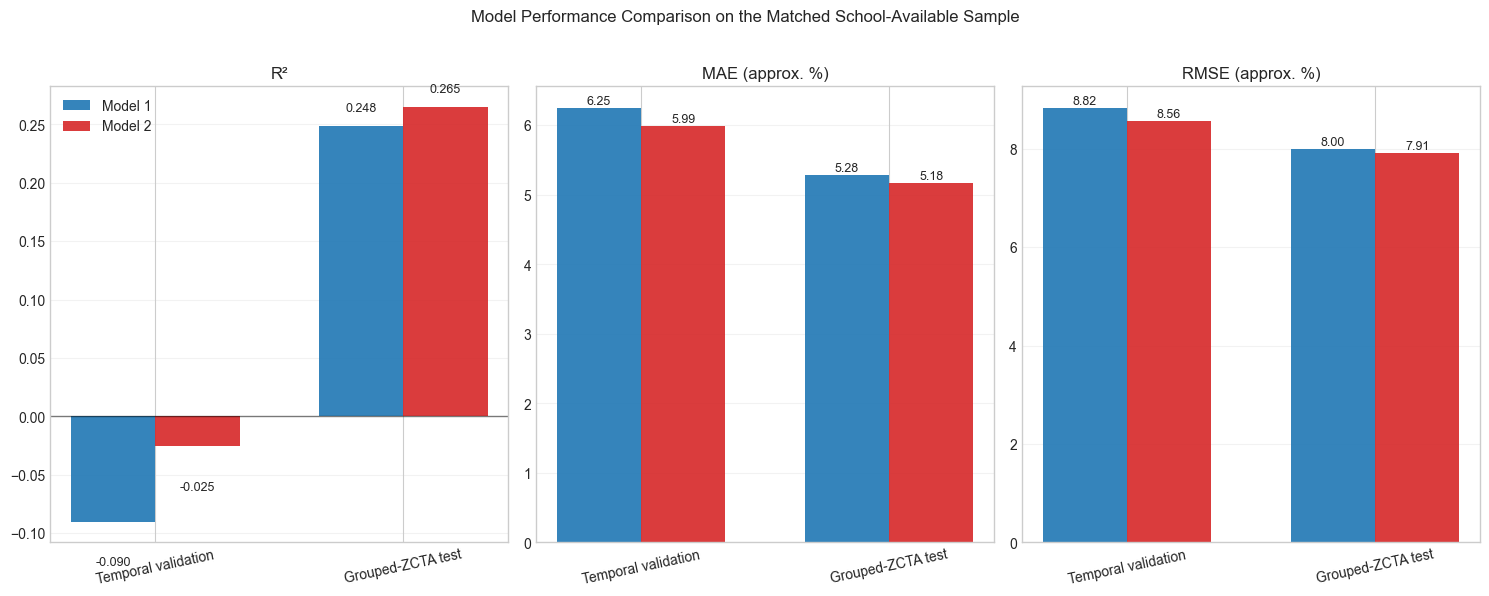

,model,evaluation,rows,r2,mae_pct_approx,rmse_pct_approx
2,Model 1,Temporal validation,2523,-0.090184,6.248416,8.824041
4,Model 2,Temporal validation,2523,-0.025376,5.990556,8.557741
3,Model 1,Grouped-ZCTA test,1751,0.248352,5.280012,8.003135
5,Model 2,Grouped-ZCTA test,1751,0.264846,5.175170,7.914836


In [10]:
comparison_df = metrics_df[metrics_df['sample'] == 'Matched school sample'].copy()
comparison_df['evaluation'] = pd.Categorical(
    comparison_df['evaluation'], categories=['Temporal validation', 'Grouped-ZCTA test'], ordered=True
)
comparison_df['model'] = pd.Categorical(
    comparison_df['model'], categories=['Model 1', 'Model 2'], ordered=True
)
comparison_df = comparison_df.sort_values(['evaluation', 'model'])

metrics_to_plot = [
    ('r2', 'R²', False),
    ('mae_pct_approx', 'MAE (approx. %)', True),
    ('rmse_pct_approx', 'RMSE (approx. %)', True),
]

x = np.arange(2)
width = 0.34
model_colors = {'Model 1': '#1f77b4', 'Model 2': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.8))
for ax, (metric_column, title, is_error_metric) in zip(axes, metrics_to_plot):
    for i, model_name in enumerate(['Model 1', 'Model 2']):
        subset = comparison_df[comparison_df['model'] == model_name].set_index('evaluation').reindex(['Temporal validation', 'Grouped-ZCTA test'])
        offset = (-width / 2) if i == 0 else (width / 2)
        bars = ax.bar(x + offset, subset[metric_column].values, width=width, label=model_name, color=model_colors[model_name], alpha=0.9)
        for bar in bars:
            value = bar.get_height()
            label = f'{value:.2f}' if metric_column != 'r2' else f'{value:.3f}'
            y_text = value + 0.01 if value >= 0 else value - 0.03
            va = 'bottom' if value >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width() / 2, y_text, label, ha='center', va=va, fontsize=9)
    if not is_error_metric:
        ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(['Temporal validation', 'Grouped-ZCTA test'], rotation=12)
    ax.grid(axis='y', alpha=0.25)

axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Model Performance Comparison on the Matched School-Available Sample', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_model_performance_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
comparison_df[['model', 'evaluation', 'rows', 'r2', 'mae_pct_approx', 'rmse_pct_approx']]